# <span style="color:blue"><b>PROYECTO FINAL</b></span>

# <span style="color:blue"><b>SISTEMA DE AUTENTICACIÓN MULTIPARTE DE CARTERAS</b></span>


#Integrantes
### ● Jesus Campos
### ● Marco Barrera



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive

MyDrive


In [2]:
!ls /content/drive/MyDrive/PI_II

 Autenticacion_Carteras__Metricas_v03.ipynb
 Autenticacion_Carteras__Metricas_v07.ipynb
 Autenticacion_Carteras__Metricas_v08.ipynb
 Autenticacion_Carteras__Metricas_v09.ipynb
 Chanel_Parts_00.zip
 Chanel_Parts.zip
 chanel.zip
 Ch_parts_v2
 DATASET
 DATASET.zip
'Guía Experta: Autenticación de Carteras Chanel.gdoc'
 history_mobile.pkl
 history_mobilev3.pkl
 history_resnet.pkl
 modelo_autenticacion.h5
 modelo_autenticacion.keras
 modelo_EfficientNetB3.keras
 modelo_logo_turnlock_balanceado.keras
 modelo_logo_turnlock_corregido.keras
 modelo_logo_turnlock.keras
 modelo_mobilenetv2_logo_turnlock.keras
 modelo_mobilenetv3_logo_turnlock.keras
 modelo_resnet50_logo_turnlock.keras
 pipeline_autenticacion.docx
 pipeline_autenticacion_v2.docx
 Proyecto_Pipeline_COMPLETO.docx
 Proyecto_Pipeline.docx
 Proyecto_Pipeline_final.docx
 VERSION_01
 VERSION_02
 yolo_chanel.ipynb


In [3]:
import shutil
import os

SRC_ZIP = "/content/drive/MyDrive/PI_II/chanel.zip"
DST_ZIP = "/content/chanel.zip"

print("Copiando ZIP a disco local...")
shutil.copy2(SRC_ZIP, DST_ZIP)
print("ZIP copiado a /content/")


Copiando ZIP a disco local...
ZIP copiado a /content/


In [4]:
import zipfile

with zipfile.ZipFile("/content/chanel.zip", "r") as z:
    for name in z.namelist()[:30]:
        print(name)

chanel/
chanel/fake/
chanel/fake/bag---2.55/
chanel/fake/bag---2.55/0104/
chanel/fake/bag---2.55/0104/0104_1.jpg
chanel/fake/bag---2.55/0104/0104_2.jpg
chanel/fake/bag---2.55/0104/0104_3.jpg
chanel/fake/bag---2.55/0104/0104_4.jpg
chanel/fake/bag---2.55/0105/
chanel/fake/bag---2.55/0105/0105_1.jpg
chanel/fake/bag---2.55/0105/0105_2.jpg
chanel/fake/bag---2.55/0105/0105_3.jpg
chanel/fake/bag---2.55/0105/0105_4.jpg
chanel/fake/bag---2.55/0105/0105_5.jpg
chanel/fake/bag---2.55/0106/
chanel/fake/bag---2.55/0106/0106_1.jpg
chanel/fake/bag---2.55/0106/0106_2.jpg
chanel/fake/bag---2.55/0107/
chanel/fake/bag---2.55/0107/0107_1.jpg
chanel/fake/bag---2.55/0107/0107_2.jpg
chanel/fake/bag---2.55/0107/0107_3.jpg
chanel/fake/bag---2.55/0107/0107_4.jpg
chanel/fake/bag---2.55/0107/0107_5.jpg
chanel/fake/bag---2.55/0107/0107_6.jpg
chanel/fake/bag---2.55/0107/0107_7.jpg
chanel/fake/bag---2.55/0107/0107_8.jpg
chanel/fake/bag---2.55/0107/0107_9.jpg
chanel/fake/bag---2.55/0108/
chanel/fake/bag---2.55/0108/01

In [5]:
import zipfile

EXTRACT_DIR = "/content/data"
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Descomprimiendo ZIP en /content/data...")
with zipfile.ZipFile(DST_ZIP, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset descomprimido en /content/data")

Descomprimiendo ZIP en /content/data...
Dataset descomprimido en /content/data


In [6]:
!ls /content/data/chanel

fake  genuine


### <span style="color:#800020"><b>Entrenamiento del Modelo para Autenticación de Carteras</b></span>

Se entrena un modelo de clasificación binaria para distinguir entre carteras genuinas y falsas usando EfficientNetB0, MobileNetV2 y ResNet50.
Se utiliza validación y early stopping para mejorar la generalización y evitar sobreajuste.

In [7]:
import zipfile, os, shutil

ZIP_PATH = "/content/drive/MyDrive/PI_II/Chanel_Parts.zip"
DEST_DIR = "/content/Chanel_Parts"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descomprimido")
print(os.listdir(DEST_DIR))

Dataset descomprimido
['fake', 'genuine']


In [9]:
import zipfile
import os
import shutil
import pandas as pd

ZIP_PATH = "/content/drive/MyDrive/PI_II/Chanel_Parts.zip"
DEST_DIR = "/content/Chanel_Parts"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descomprimido")

# extensiones válidas de imágenes
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

data = []

for root, dirs, files in os.walk(DEST_DIR):
    img_count = sum(1 for f in files if f.lower().endswith(IMG_EXT))

    if img_count > 0:
        rel_path = os.path.relpath(root, DEST_DIR)
        data.append([rel_path, img_count])

df = pd.DataFrame(data, columns=["Carpeta", "Cantidad_Imagenes"])

# ordenar por cantidad
df = df.sort_values(by="Cantidad_Imagenes", ascending=False)

# mostrar tabla
print(df.to_string(index=False))

# total general
print("\nTOTAL DE IMÁGENES:", df["Cantidad_Imagenes"].sum())

Dataset descomprimido
           Carpeta  Cantidad_Imagenes
 genuine/bag---boy               1632
genuine/bag---2.55                414
   fake/bag---2.55                200
    fake/bag---boy                200

TOTAL DE IMÁGENES: 2446


### <span style="color:#800020"><b>Modelo de Partes EfficientNetB3</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura EfficientNetB3 mediante transferencia de aprendizaje

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import time

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (300,300)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(300,300,3)
)

base_model.trainable = False

model = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

class TimeHistory(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.train_start = time.time()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        self.epoch_times.append(elapsed)
        print(f"\nTiempo época {epoch+1}: {elapsed:.2f} segundos")

    def on_train_end(self, logs=None):
        total_time = time.time() - self.train_start

        print("\nTiempo por época:")
        for i, t in enumerate(self.epoch_times):
            print(f"Época {i+1}: {t:.2f} segundos")

        print(f"\nTiempo total: {total_time:.2f} segundos")
        print(f"Tiempo total: {total_time/60:.2f} minutos")

time_callback = TimeHistory()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[time_callback]
)

model.save("/content/drive/MyDrive/PI_II/modelo_EfficientNetB3.keras")

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.6465 - loss: 0.6519
Tiempo época 1: 133.21 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 133s 614ms/step - accuracy: 0.6668 - loss: 0.6678 - val_accuracy: 0.7464 - val_loss: 0.5929
Epoch 2/20
121/123 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6747 - loss: 0.5909
Tiempo época 2: 2.94 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7041 - loss: 0.6017 - val_accuracy: 0.7894 - val_loss: 0.5492
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7385 - loss: 0.5630
Tiempo época 3: 2.93 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7404 - loss: 0.5740 - val_accuracy: 0.7955 - val_loss: 0.5212
Epo

### <span style="color:#800020"><b>Modelo de Partes MobileNetV3</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura MobileNetV3 mediante transferencia de aprendizaje

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Large
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pickle
import time

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model_mobilev3 = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_mobilev3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

class TimeHistory(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.train_start = time.time()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        self.epoch_times.append(elapsed)
        print(f"\nTiempo época {epoch+1}: {elapsed:.2f} segundos")

    def on_train_end(self, logs=None):
        total_time = time.time() - self.train_start

        print("\nTiempo por época:")
        for i, t in enumerate(self.epoch_times):
            print(f"Época {i+1}: {t:.2f} segundos")

        print(f"\nTiempo total de entrenamiento: {total_time:.2f} segundos")
        print(f"Tiempo total de entrenamiento: {total_time/60:.2f} minutos")

time_callback = TimeHistory()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_mobilev3 = model_mobilev3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, time_callback]
)

print("Mejor Val Accuracy MobileNetV3Large:",
      max(history_mobilev3.history["val_accuracy"]))

print("Mejor Val Loss MobileNetV3Large:",
      min(history_mobilev3.history["val_loss"]))

model_mobilev3.save(
    "/content/drive/MyDrive/PI_II/modelo_mobilenetv3_logo_turnlock.keras"
)

with open("/content/drive/MyDrive/PI_II/history_mobilev3.pkl", "wb") as f:
    pickle.dump(history_mobilev3.history, f)

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.5790 - loss: 0.8490
Tiempo época 1: 61.15 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 61s 311ms/step - accuracy: 0.5738 - loss: 0.8473 - val_accuracy: 0.5890 - val_loss: 0.6784
Epoch 2/20
121/123 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5342 - loss: 0.7669
Tiempo época 2: 1.76 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5677 - loss: 0.7594 - val_accuracy: 0.6544 - val_loss: 0.6191
Epoch 3/20
119/123 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5935 - loss: 0.6623
Tiempo época 3: 1.74 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6280 - loss: 0.6699 - val_accuracy: 0.7301 - val_loss: 0.5513
Epoch

### <span style="color:#800020"><b>Modelo de Partes ResNet50</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura ResNet50 mediante transferencia de aprendizaje

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pickle
import time

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model_resnet = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

class TimeHistory(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.train_start = time.time()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        self.epoch_times.append(elapsed)
        print(f"\nTiempo época {epoch+1}: {elapsed:.2f} segundos")

    def on_train_end(self, logs=None):
        total_time = time.time() - self.train_start

        print("\nTiempo por época:")
        for i, t in enumerate(self.epoch_times):
            print(f"Época {i+1}: {t:.2f} segundos")

        print(f"\nTiempo total de entrenamiento: {total_time:.2f} segundos")
        print(f"Tiempo total de entrenamiento: {total_time/60:.2f} minutos")

time_callback = TimeHistory()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, time_callback]
)

print("Mejor Val Accuracy ResNet50:",
      max(history_resnet.history["val_accuracy"]))

print("Mejor Val Loss ResNet50:",
      min(history_resnet.history["val_loss"]))

model_resnet.save(
    "/content/drive/MyDrive/PI_II/modelo_resnet50_logo_turnlock.keras"
)

with open("/content/drive/MyDrive/PI_II/history_resnet.pkl", "wb") as f:
    pickle.dump(history_resnet.history, f)

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5924 - loss: 0.8541
Tiempo época 1: 24.16 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step - accuracy: 0.5626 - loss: 0.8360 - val_accuracy: 0.6217 - val_loss: 0.7129
Epoch 2/20
118/123 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5893 - loss: 0.7169
Tiempo época 2: 2.16 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6208 - loss: 0.6972 - val_accuracy: 0.7382 - val_loss: 0.5881
Epoch 3/20
119/123 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6924 - loss: 0.5652
Tiempo época 3: 2.27 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6949 - loss: 0.5826 - val_accuracy: 0.7771 - val_loss: 0.5304
Epoch 

In [13]:
from tensorflow.keras.models import load_model
import tensorflow as tf
import pandas as pd

DATA_DIR = "/content/Chanel_Parts"
BATCH_SIZE = 16

val_ds_224 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=BATCH_SIZE
)

val_ds_300 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(300, 300),
    batch_size=BATCH_SIZE
)

val_ds_224 = val_ds_224.prefetch(tf.data.AUTOTUNE)
val_ds_300 = val_ds_300.prefetch(tf.data.AUTOTUNE)

model_eff = load_model("/content/drive/MyDrive/PI_II/modelo_EfficientNetB3.keras")
model_mobile = load_model("/content/drive/MyDrive/PI_II/modelo_mobilenetv3_logo_turnlock.keras")
model_resnet = load_model("/content/drive/MyDrive/PI_II/modelo_resnet50_logo_turnlock.keras")

loss_eff, acc_eff = model_eff.evaluate(val_ds_300, verbose=0)
loss_mobile, acc_mobile = model_mobile.evaluate(val_ds_224, verbose=0)
loss_resnet, acc_resnet = model_resnet.evaluate(val_ds_224, verbose=0)

resultados = pd.DataFrame({
    "Modelo": ["ResNet50", "EfficientNetB3", "MobileNetV3"],
    "Accuracy": [acc_resnet, acc_eff, acc_mobile],
    "Loss": [loss_resnet, loss_eff, loss_mobile]
})

resultados["Accuracy (%)"] = resultados["Accuracy"] * 100
resultados["Error (%)"] = 100 - resultados["Accuracy (%)"]

resultados = resultados.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

resultados["Ranking"] = ["🥇", "🥈", "🥉"]

display(resultados)

Found 2446 files belonging to 2 classes.
Using 489 files for validation.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.


,Modelo,Accuracy,Loss,Accuracy (%),Error (%),Ranking
0,ResNet50,0.930470,0.232789,93.047035,6.952965,🥇
1,MobileNetV3,0.924335,0.258596,92.433536,7.566464,🥈
2,EfficientNetB3,0.901841,0.330935,90.184051,9.815949,🥉


In [14]:
print("history" in globals())
print("history_resnet" in globals())
print("history_mobilev3" in globals())

True
True
True


**Precisión de Entrenamiento y Validación**

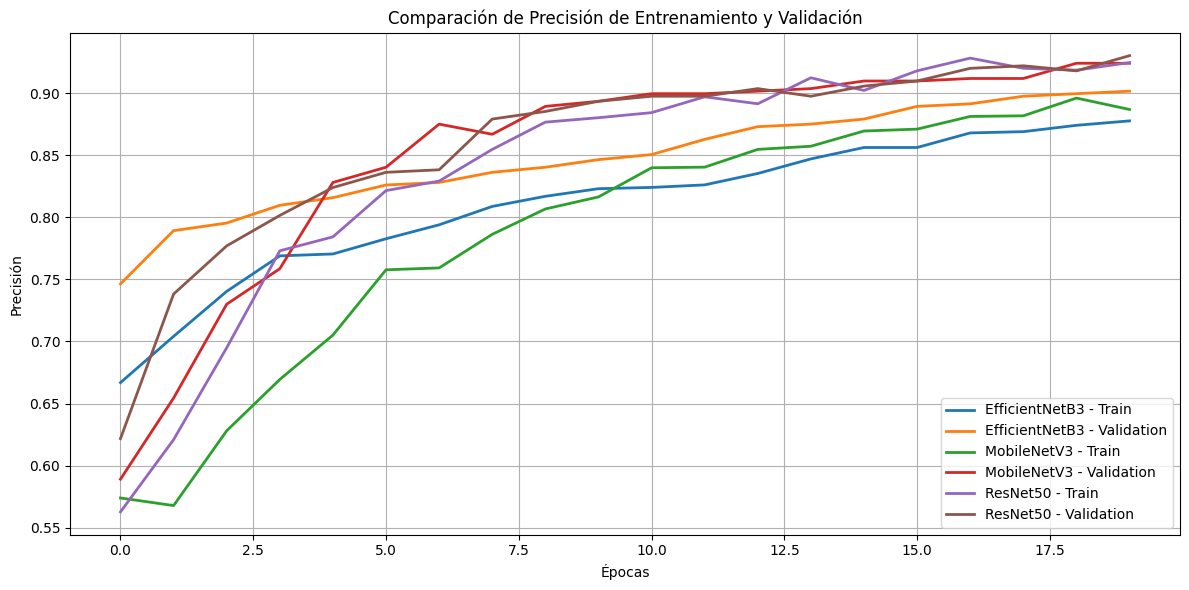

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(history.history['accuracy'],
         label='EfficientNetB3 - Train',
         linewidth=2)

plt.plot(history.history['val_accuracy'],
         label='EfficientNetB3 - Validation',
         linewidth=2)

plt.plot(history_mobilev3.history['accuracy'],
         label='MobileNetV3 - Train',
         linewidth=2)

plt.plot(history_mobilev3.history['val_accuracy'],
         label='MobileNetV3 - Validation',
         linewidth=2)

plt.plot(history_resnet.history['accuracy'],
         label='ResNet50 - Train',
         linewidth=2)

plt.plot(history_resnet.history['val_accuracy'],
         label='ResNet50 - Validation',
         linewidth=2)

plt.title('Comparación de Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

**Loss de Entrenamiento vs Validación**

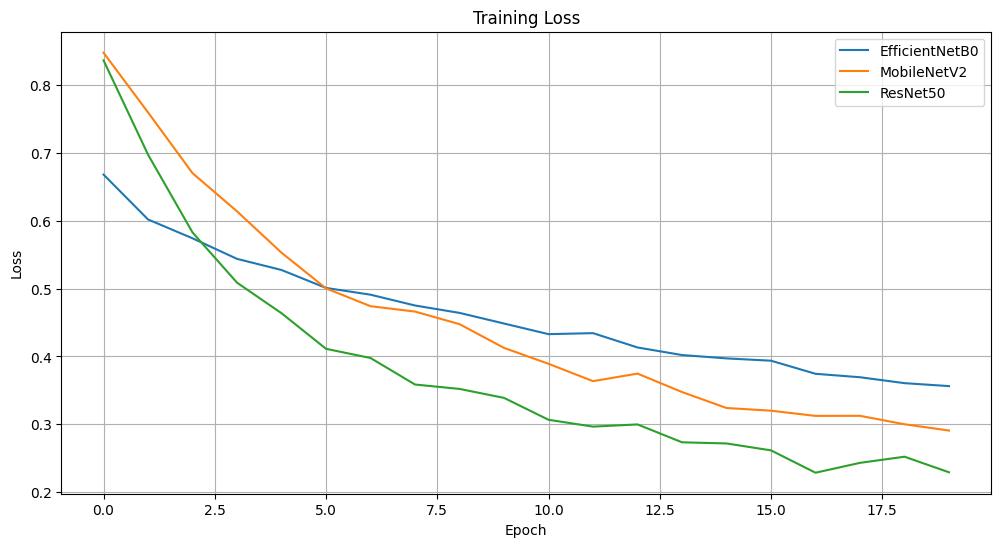

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(history.history['loss'], label='EfficientNetB0')
plt.plot(history_mobilev3.history['loss'], label='MobileNetV2')
plt.plot(history_resnet.history['loss'], label='ResNet50')

plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
import pandas as pd

df_metricas = pd.DataFrame({
    "Modelo": ["EfficientNetB3", "MobileNetV3", "ResNet50"],
    "Mejor Val Accuracy": [
        max(history.history["val_accuracy"]),
        max(history_mobilev3.history["val_accuracy"]),
        max(history_resnet.history["val_accuracy"])
    ],
    "Mejor Val Loss": [
        min(history.history["val_loss"]),
        min(history_mobilev3.history["val_loss"]),
        min(history_resnet.history["val_loss"])
    ],
    "Épocas entrenadas": [
        len(history.history["accuracy"]),
        len(history_mobilev3.history["accuracy"]),
        len(history_resnet.history["accuracy"])
    ]
})

df_metricas["Accuracy (%)"] = df_metricas["Mejor Val Accuracy"] * 100
df_metricas["Error (%)"] = 100 - df_metricas["Accuracy (%)"]

df_metricas = df_metricas.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

df_metricas["Ranking"] = ["🥇", "🥈", "🥉"]

display(df_metricas)

,Modelo,Mejor Val Accuracy,Mejor Val Loss,Épocas entrenadas,Accuracy (%),Error (%),Ranking
0,ResNet50,0.930470,0.232789,20,93.047035,6.952965,🥇
1,MobileNetV3,0.924335,0.258595,20,92.433536,7.566464,🥈
2,EfficientNetB3,0.901841,0.330935,20,90.184051,9.815949,🥉


**# Comparativa de los 3 Modelos**

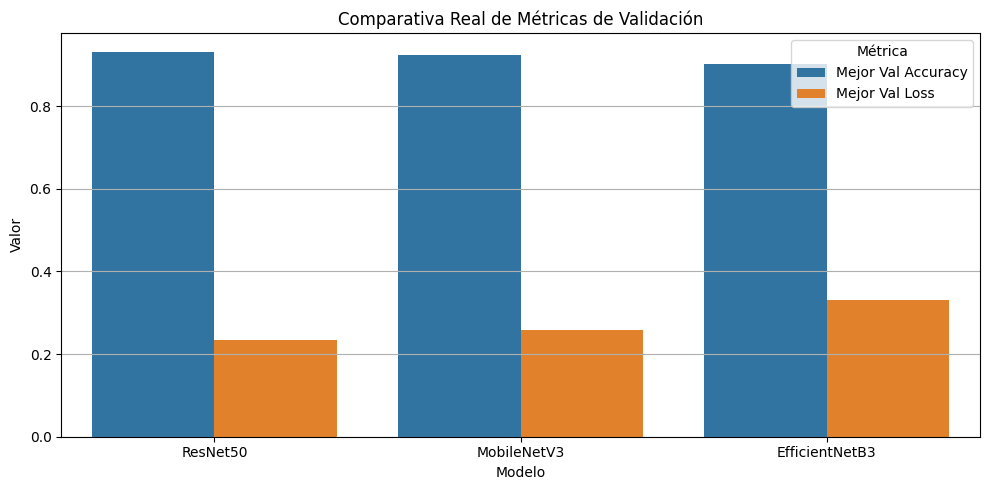

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_metricas.melt(
    id_vars="Modelo",
    value_vars=["Mejor Val Accuracy", "Mejor Val Loss"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_plot,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Comparativa Real de Métricas de Validación")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**Matriz de Confusión del Modelo de Autenticación de Partes**

Found 2446 files belonging to 2 classes.
Using 489 files for validation.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.


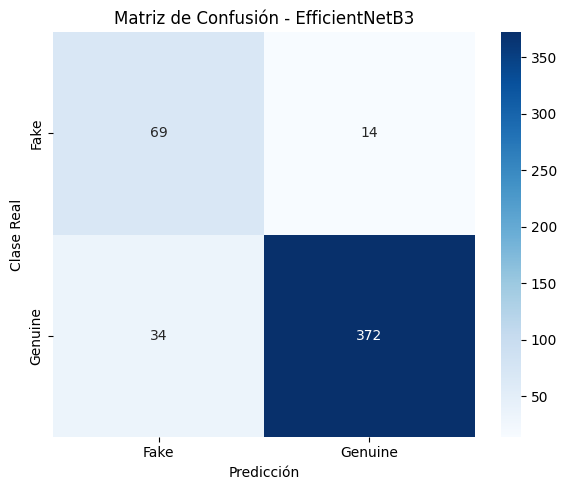


===== EfficientNetB3 =====
              precision    recall  f1-score   support

        Fake       0.67      0.83      0.74        83
     Genuine       0.96      0.92      0.94       406

    accuracy                           0.90       489
   macro avg       0.82      0.87      0.84       489
weighted avg       0.91      0.90      0.91       489



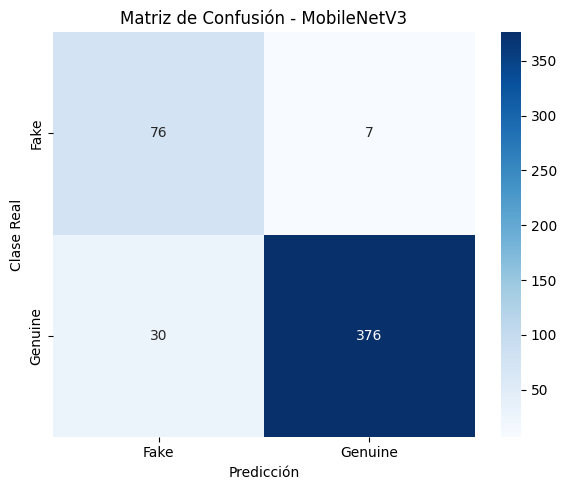


===== MobileNetV3 =====
              precision    recall  f1-score   support

        Fake       0.72      0.92      0.80        83
     Genuine       0.98      0.93      0.95       406

    accuracy                           0.92       489
   macro avg       0.85      0.92      0.88       489
weighted avg       0.94      0.92      0.93       489



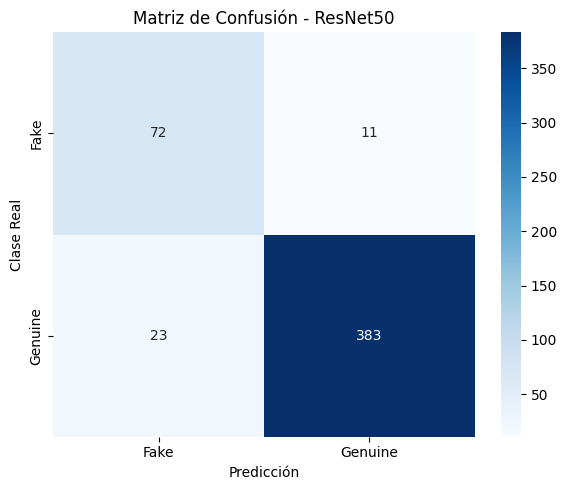


===== ResNet50 =====
              precision    recall  f1-score   support

        Fake       0.76      0.87      0.81        83
     Genuine       0.97      0.94      0.96       406

    accuracy                           0.93       489
   macro avg       0.86      0.91      0.88       489
weighted avg       0.94      0.93      0.93       489



In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

DATA_DIR = "/content/Chanel_Parts"
BATCH_SIZE = 16

class_names = ['Fake', 'Genuine']

val_ds_224 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=BATCH_SIZE
)

val_ds_300 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(300, 300),
    batch_size=BATCH_SIZE
)

val_ds_224 = val_ds_224.prefetch(tf.data.AUTOTUNE)
val_ds_300 = val_ds_300.prefetch(tf.data.AUTOTUNE)

modelos = {
    "EfficientNetB3": (model_eff, val_ds_300),
    "MobileNetV3": (model_mobile, val_ds_224),
    "ResNet50": (model_resnet, val_ds_224)
}

for nombre, (modelo, dataset) in modelos.items():

    y_true = []
    y_prob = []

    for x_batch, y_batch in dataset:
        pred = modelo.predict(x_batch, verbose=0)
        y_prob.extend(pred.ravel())
        y_true.extend(y_batch.numpy().ravel())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f'Matriz de Confusión - {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Clase Real')
    plt.tight_layout()
    plt.show()

    print(f'\n===== {nombre} =====')
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

**K-Fold Cross Validation del Umbral Global**

Found 2446 files belonging to 2 classes.
Using 489 files for validation.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.


,Modelo,Fold,Mejor Umbral,Accuracy,Precision,Recall,F1-Score
0,EfficientNetB3,1,0.63,0.806122,1.000000,0.768293,0.868966
1,EfficientNetB3,2,0.76,0.683673,1.000000,0.617284,0.763359
2,EfficientNetB3,3,0.57,0.918367,0.986667,0.913580,0.948718
3,EfficientNetB3,4,0.54,0.897959,0.986301,0.888889,0.935065
4,EfficientNetB3,5,0.55,0.855670,0.971831,0.851852,0.907895
5,MobileNetV3,1,0.50,0.918367,0.986842,0.914634,0.949367
6,MobileNetV3,2,0.56,0.918367,0.986667,0.913580,0.948718
7,MobileNetV3,3,0.55,0.969388,1.000000,0.962963,0.981132
8,MobileNetV3,4,0.63,0.877551,1.000000,0.851852,0.920000
9,MobileNetV3,5,0.50,0.886598,0.972973,0.888889,0.929032


Mejor Umbral                   Accuracy Precision    Recall  \
                       mean median       std      mean      mean      mean   
Modelo                                                                       
EfficientNetB3        0.610   0.57  0.090830  0.832359  0.988960  0.807980   
MobileNetV3           0.548   0.55  0.053572  0.914054  0.989296  0.906384   
ResNet50              0.614   0.58  0.132212  0.893457  0.989568  0.881632   

                F1-Score  
                    mean  
Modelo                    
EfficientNetB3  0.884800  
MobileNetV3     0.945650  
ResNet50        0.930844

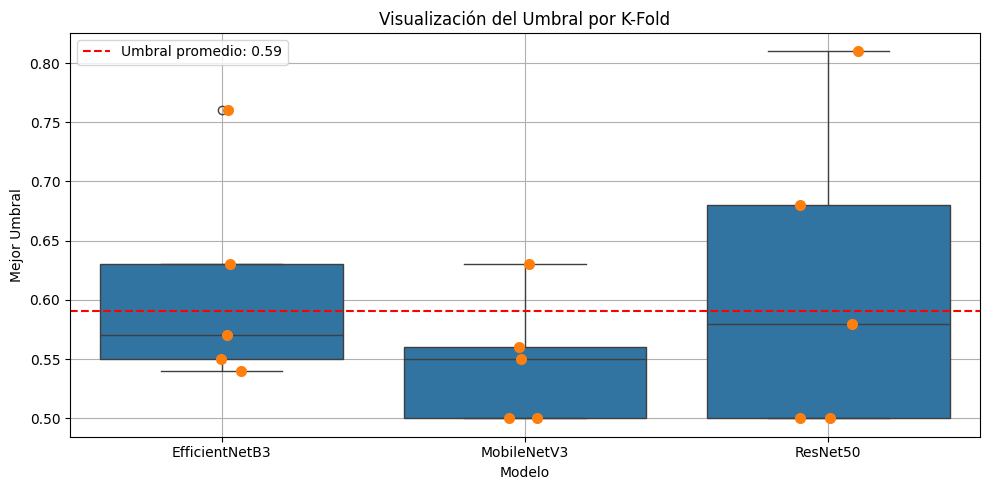

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

DATA_DIR = "/content/Chanel_Parts"
BATCH_SIZE = 16

val_ds_224 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=BATCH_SIZE
)

val_ds_300 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(300, 300),
    batch_size=BATCH_SIZE
)

val_ds_224 = val_ds_224.prefetch(tf.data.AUTOTUNE)
val_ds_300 = val_ds_300.prefetch(tf.data.AUTOTUNE)

modelos = {
    "EfficientNetB3": (model_eff, val_ds_300),
    "MobileNetV3": (model_mobile, val_ds_224),
    "ResNet50": (model_resnet, val_ds_224)
}

umbrales = np.arange(0.50, 0.96, 0.01)

resultados = []

for nombre, (modelo, dataset) in modelos.items():

    y_true = []
    y_prob = []

    for x_batch, y_batch in dataset:
        pred = modelo.predict(x_batch, verbose=0)
        y_prob.extend(pred.ravel())
        y_true.extend(y_batch.numpy().ravel())

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    for fold, (_, test_idx) in enumerate(
        skf.split(y_prob, y_true),
        start=1
    ):

        y_true_fold = y_true[test_idx]
        y_prob_fold = y_prob[test_idx]

        mejor_score = -1
        mejor_umbral = 0
        mejor_accuracy = 0
        mejor_precision = 0
        mejor_recall = 0
        mejor_f1 = 0

        for umbral in umbrales:

            y_pred_fold = (y_prob_fold >= umbral).astype(int)

            accuracy = accuracy_score(y_true_fold, y_pred_fold)

            precision = precision_score(
                y_true_fold,
                y_pred_fold,
                zero_division=0
            )

            recall = recall_score(
                y_true_fold,
                y_pred_fold,
                zero_division=0
            )

            f1 = f1_score(
                y_true_fold,
                y_pred_fold,
                zero_division=0
            )

            score = (0.90 * precision) + (0.10 * recall)

            if score > mejor_score:
                mejor_score = score
                mejor_umbral = umbral
                mejor_accuracy = accuracy
                mejor_precision = precision
                mejor_recall = recall
                mejor_f1 = f1

        resultados.append([
            nombre,
            fold,
            round(mejor_umbral, 2),
            mejor_accuracy,
            mejor_precision,
            mejor_recall,
            mejor_f1
        ])

df_kfold = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "Fold",
        "Mejor Umbral",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

display(df_kfold)

resumen = (
    df_kfold
    .groupby("Modelo")
    .agg({
        "Mejor Umbral": ["mean", "median", "std"],
        "Accuracy": "mean",
        "Precision": "mean",
        "Recall": "mean",
        "F1-Score": "mean"
    })
)

display(resumen)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_kfold,
    x="Modelo",
    y="Mejor Umbral"
)

sns.stripplot(
    data=df_kfold,
    x="Modelo",
    y="Mejor Umbral",
    size=8,
    jitter=True
)

plt.axhline(
    df_kfold["Mejor Umbral"].mean(),
    color="red",
    linestyle="--",
    label=f'Umbral promedio: {df_kfold["Mejor Umbral"].mean():.2f}'
)

plt.title("Visualización del Umbral por K-Fold")
plt.xlabel("Modelo")
plt.ylabel("Mejor Umbral")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

DATA_DIR = "/content/Chanel_Parts"
BATCH_SIZE = 16
class_names = ['Fake', 'Genuine']

val_ds_slice = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=BATCH_SIZE,
    shuffle=False
)

file_paths = np.array(val_ds_slice.file_paths)

y_true = []
y_prob = []

for x_batch, y_batch in val_ds_slice:
    pred = model_resnet.predict(x_batch, verbose=0)
    y_prob.extend(pred.ravel())
    y_true.extend(y_batch.numpy().ravel())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

def extraer_modelo(path):
    p = path.lower()
    if "boy" in p:
        return "Boy"
    elif "2.55" in p or "2_55" in p or "255" in p:
        return "2.55"
    else:
        return "Desconocido"

def extraer_parte(path):
    p = path.lower()
    if "logo" in p:
        return "Logo"
    elif "turnlock" in p or "lock" in p:
        return "Turnlock"
    else:
        return "Desconocido"

df_error = pd.DataFrame({
    "path": file_paths,
    "filename": [os.path.basename(p) for p in file_paths],
    "modelo_cartera": [extraer_modelo(p) for p in file_paths],
    "parte": [extraer_parte(p) for p in file_paths],
    "y_true": y_true,
    "y_prob": y_prob,
    "y_pred": y_pred
})

df_error["real"] = df_error["y_true"].map({0: "Fake", 1: "Genuine"})
df_error["prediccion"] = df_error["y_pred"].map({0: "Fake", 1: "Genuine"})
df_error["error"] = df_error["y_true"] != df_error["y_pred"]

df_error["tipo_error"] = np.select(
    [
        (df_error["y_true"] == 0) & (df_error["y_pred"] == 1),
        (df_error["y_true"] == 1) & (df_error["y_pred"] == 0)
    ],
    [
        "FP",
        "FN"
    ],
    default="Correcto"
)

df_error["slice_modelo_parte"] = df_error["modelo_cartera"] + " + " + df_error["parte"]

display(df_error)

Found 2446 files belonging to 2 classes.
Using 489 files for validation.


,path,filename,modelo_cartera,parte,y_true,y_prob,y_pred,real,prediccion,error,tipo_error,slice_modelo_parte
0,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0617.jpg,Boy,Turnlock,1,0.940624,1,Genuine,Genuine,False,Correcto,Boy + Turnlock
1,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0618.jpg,Boy,Turnlock,1,0.882826,1,Genuine,Genuine,False,Correcto,Boy + Turnlock
2,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0619.jpg,Boy,Turnlock,1,0.948212,1,Genuine,Genuine,False,Correcto,Boy + Turnlock
3,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0620.jpg,Boy,Turnlock,1,0.946985,1,Genuine,Genuine,False,Correcto,Boy + Turnlock
4,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0621.jpg,Boy,Turnlock,1,0.908039,1,Genuine,Genuine,False,Correcto,Boy + Turnlock
...,...,...,...,...,...,...,...,...,...,...,...,...
484,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_1146.jpg,Boy,Turnlock,1,0.917402,1,Genuine,Genuine,False,Correcto,Boy + Turnlock
485,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_1147.jpg,Boy,Turnlock,1,0.972519,1,Genuine,Genuine,False,Correcto,Boy + Turnlock
486,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_1148.jpg,Boy,Turnlock,1,0.948126,1,Genuine,Genuine,False,Correcto,Boy + Turnlock
487,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_1149.jpg,Boy,Turnlock,1,0.973313,1,Genuine,Genuine,False,Correcto,Boy + Turnlock


In [26]:
def calcular_metricas_slice(df, slice_col):
    resultados = []

    for slice_name, g in df.groupby(slice_col):
        if len(g) < 2:
            continue

        y_t = g["y_true"].values
        y_p = g["y_pred"].values
        y_pr = g["y_prob"].values

        tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()

        try:
            roc_auc = roc_auc_score(y_t, y_pr)
        except:
            roc_auc = np.nan

        try:
            pr_auc = average_precision_score(y_t, y_pr)
        except:
            pr_auc = np.nan

        resultados.append({
            "slice_variable": slice_col,
            "slice": slice_name,
            "n": len(g),
            "accuracy": accuracy_score(y_t, y_p),
            "precision": precision_score(y_t, y_p, zero_division=0),
            "recall": recall_score(y_t, y_p, zero_division=0),
            "f1": f1_score(y_t, y_p, zero_division=0),
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "error_rate": g["error"].mean()
        })

    return pd.DataFrame(resultados)

df_metricas_slices = pd.concat([
    calcular_metricas_slice(df_error, "modelo_cartera"),
    calcular_metricas_slice(df_error, "parte"),
    calcular_metricas_slice(df_error, "real"),
    calcular_metricas_slice(df_error, "slice_modelo_parte")
], ignore_index=True)

df_metricas_slices = df_metricas_slices.sort_values(
    by=["error_rate", "f1"],
    ascending=[False, True]
)

display(df_metricas_slices)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,slice_variable,slice,n,accuracy,precision,recall,f1,roc_auc,pr_auc,TP,FP,FN,TN,error_rate
0,modelo_cartera,Boy,489,0.977505,1.0,0.977505,0.988625,NaN,1.0,478,0,11,0,0.022495
1,parte,Turnlock,489,0.977505,1.0,0.977505,0.988625,NaN,1.0,478,0,11,0,0.022495
2,real,Genuine,489,0.977505,1.0,0.977505,0.988625,NaN,1.0,478,0,11,0,0.022495
3,slice_modelo_parte,Boy + Turnlock,489,0.977505,1.0,0.977505,0.988625,NaN,1.0,478,0,11,0,0.022495


In [27]:
def bootstrap_ci_metric(y_true, y_pred, metric_func, n_bootstrap=1000, alpha=0.05):
    rng = np.random.default_rng(42)
    scores = []
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n = len(y_true)

    for _ in range(n_bootstrap):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        try:
            scores.append(metric_func(y_true[idx], y_pred[idx]))
        except:
            pass

    return np.percentile(scores, 100 * alpha / 2), np.percentile(scores, 100 * (1 - alpha / 2))

resultados_ci = []

for slice_col in ["modelo_cartera", "parte", "real", "slice_modelo_parte"]:
    for slice_name, g in df_error.groupby(slice_col):
        if len(g) < 10:
            continue

        y_t = g["y_true"].values
        y_p = g["y_pred"].values

        acc_low, acc_high = bootstrap_ci_metric(y_t, y_p, accuracy_score)
        f1_low, f1_high = bootstrap_ci_metric(
            y_t,
            y_p,
            lambda a, b: f1_score(a, b, zero_division=0)
        )

        resultados_ci.append({
            "slice_variable": slice_col,
            "slice": slice_name,
            "n": len(g),
            "accuracy": accuracy_score(y_t, y_p),
            "accuracy_IC_95": f"[{acc_low:.3f}, {acc_high:.3f}]",
            "f1": f1_score(y_t, y_p, zero_division=0),
            "f1_IC_95": f"[{f1_low:.3f}, {f1_high:.3f}]"
        })

df_ci = pd.DataFrame(resultados_ci)

display(df_ci)

,slice_variable,slice,n,accuracy,accuracy_IC_95,f1,f1_IC_95
0,modelo_cartera,Boy,489,0.977505,"[0.963, 0.990]",0.988625,"[0.981, 0.995]"
1,parte,Turnlock,489,0.977505,"[0.963, 0.990]",0.988625,"[0.981, 0.995]"
2,real,Genuine,489,0.977505,"[0.963, 0.990]",0.988625,"[0.981, 0.995]"
3,slice_modelo_parte,Boy + Turnlock,489,0.977505,"[0.963, 0.990]",0.988625,"[0.981, 0.995]"


In [28]:
MIN_N = 10

df_slices_problematicos = df_metricas_slices[
    df_metricas_slices["n"] >= MIN_N
].sort_values(
    by=["error_rate", "FN", "FP"],
    ascending=[False, False, False]
)

display(df_slices_problematicos)

peor_slice = df_slices_problematicos.iloc[0]

print("Variable:", peor_slice["slice_variable"])
print("Slice:", peor_slice["slice"])
print("n:", peor_slice["n"])
print("Error rate:", round(peor_slice["error_rate"], 4))
print("F1:", round(peor_slice["f1"], 4))
print("FP:", peor_slice["FP"])
print("FN:", peor_slice["FN"])

,slice_variable,slice,n,accuracy,precision,recall,f1,roc_auc,pr_auc,TP,FP,FN,TN,error_rate
0,modelo_cartera,Boy,489,0.977505,1.0,0.977505,0.988625,NaN,1.0,478,0,11,0,0.022495
1,parte,Turnlock,489,0.977505,1.0,0.977505,0.988625,NaN,1.0,478,0,11,0,0.022495
2,real,Genuine,489,0.977505,1.0,0.977505,0.988625,NaN,1.0,478,0,11,0,0.022495
3,slice_modelo_parte,Boy + Turnlock,489,0.977505,1.0,0.977505,0.988625,NaN,1.0,478,0,11,0,0.022495


Variable: modelo_cartera
Slice: Boy
n: 489
Error rate: 0.0225
F1: 0.9886
FP: 0
FN: 11


No hay errores: FP


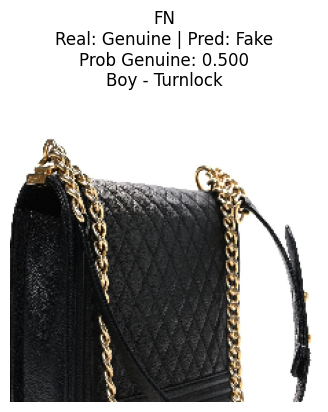

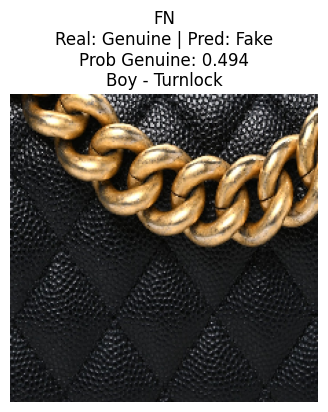

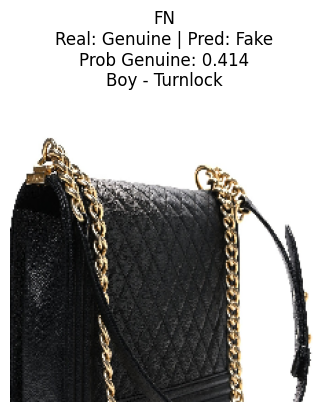

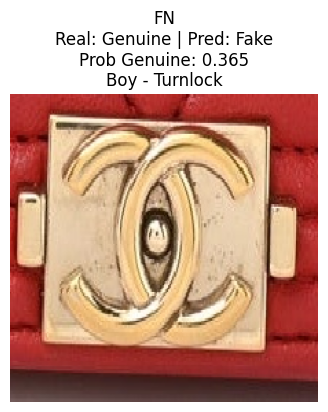

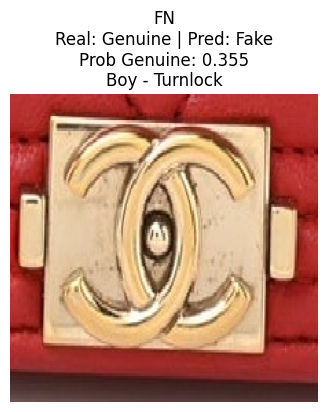

In [33]:
from tensorflow.keras.utils import load_img

def mostrar_errores(df, tipo_error, max_images=5):
    data = df[df["tipo_error"] == tipo_error].copy()

    if len(data) == 0:
        print("No hay errores:", tipo_error)
        return

    data = data.sort_values(by="y_prob", ascending=False).head(max_images)

    for _, row in data.iterrows():
        img = load_img(row["path"], target_size=(224, 224))

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"{row['tipo_error']}\n"
            f"Real: {row['real']} | Pred: {row['prediccion']}\n"
            f"Prob Genuine: {row['y_prob']:.3f}\n"
            f"{row['modelo_cartera']} - {row['parte']}"
        )
        plt.show()

mostrar_errores(df_error, "FP", 5)
mostrar_errores(df_error, "FN", 5)

In [34]:
def evaluar_con_umbral(df, umbral, experimento):
    y_t = df["y_true"].values
    y_p = (df["y_prob"].values >= umbral).astype(int)

    return {
        "experimento": experimento,
        "umbral": umbral,
        "accuracy": accuracy_score(y_t, y_p),
        "precision": precision_score(y_t, y_p, zero_division=0),
        "recall": recall_score(y_t, y_p, zero_division=0),
        "f1": f1_score(y_t, y_p, zero_division=0)
    }

df_comparacion_global = pd.DataFrame([
    evaluar_con_umbral(df_error, 0.50, "Baseline"),
    evaluar_con_umbral(df_error, mejor_umbral, "Mitigación")
])

display(df_comparacion_global)

slice_variable = peor_slice["slice_variable"]
slice_name = peor_slice["slice"]

df_peor_slice = df_error[df_error[slice_variable] == slice_name]

df_comparacion_slice = pd.DataFrame([
    evaluar_con_umbral(df_peor_slice, 0.50, "Baseline"),
    evaluar_con_umbral(df_peor_slice, mejor_umbral, "Mitigación")
])

display(df_comparacion_slice)

,experimento,umbral,accuracy,precision,recall,f1
0,Baseline,0.50,0.977505,1.0,0.977505,0.988625
1,Mitigación,0.81,0.912065,1.0,0.912065,0.954011


,experimento,umbral,accuracy,precision,recall,f1
0,Baseline,0.50,0.977505,1.0,0.977505,0.988625
1,Mitigación,0.81,0.912065,1.0,0.912065,0.954011


In [61]:
baseline_f1 = df_comparacion_global.loc[
    df_comparacion_global["experimento"] == "Baseline",
    "f1"
].values[0]

mitigacion_f1 = df_comparacion_global.loc[
    df_comparacion_global["experimento"] == "Mitigación",
    "f1"
].values[0]

baseline_slice_f1 = df_comparacion_slice.loc[
    df_comparacion_slice["experimento"] == "Baseline",
    "f1"
].values[0]

mitigacion_slice_f1 = df_comparacion_slice.loc[
    df_comparacion_slice["experimento"] == "Mitigación",
    "f1"
].values[0]

print(
    f"El análisis por slices identificó como segmento más problemático: {slice_variable} = {slice_name}. "
    f"El F1 global pasó de {baseline_f1:.3f} a {mitigacion_f1:.3f}. "
    f"El F1 del slice problemático pasó de {baseline_slice_f1:.3f} a {mitigacion_slice_f1:.3f}. "
    f"La mitigación evaluada fue el ajuste del umbral de decisión de 0.50 a {mejor_umbral:.2f}."
)

El análisis por slices identificó como segmento más problemático: modelo_cartera = Boy + Turnlock. El F1 global pasó de 0.989 a 0.954. El F1 del slice problemático pasó de 0.989 a 0.954. La mitigación evaluada fue el ajuste del umbral de decisión de 0.50 a 0.81.


In [62]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(df_error["y_true"], df_error["y_prob"])

print(f"Brier Score: {brier:.4f}")

Brier Score: 0.0221


In [63]:
from sklearn.metrics import brier_score_loss

brier_global = brier_score_loss(df_error["y_true"], df_error["y_prob"])

print(f"Brier Score global: {brier_global:.4f}")

brier_por_slice = []

for slice_col in ["modelo_cartera", "parte", "real", "slice_modelo_parte"]:
    for slice_name, g in df_error.groupby(slice_col):
        if len(g) >= 10:
            brier_por_slice.append({
                "slice_variable": slice_col,
                "slice": slice_name,
                "n": len(g),
                "brier_score": brier_score_loss(g["y_true"], g["y_prob"])
            })

df_brier_slice = pd.DataFrame(brier_por_slice)

display(df_brier_slice.sort_values(by="brier_score", ascending=False))

Brier Score global: 0.0221


,slice_variable,slice,n,brier_score
0,modelo_cartera,Boy,489,0.022084
1,parte,Turnlock,489,0.022084
2,real,Genuine,489,0.022084
3,slice_modelo_parte,Boy + Turnlock,489,0.022084


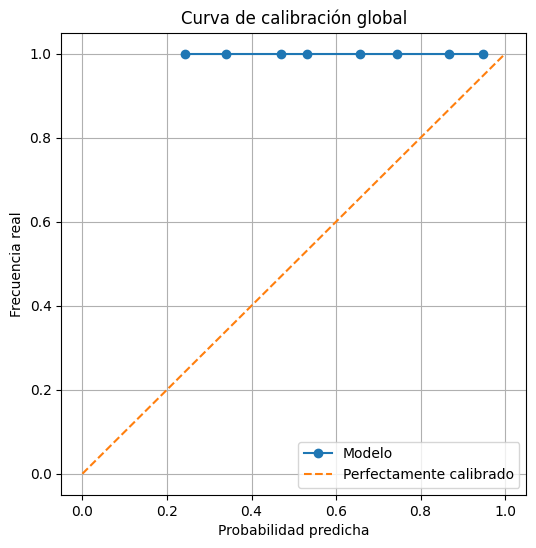

In [64]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    df_error["y_true"],
    df_error["y_prob"],
    n_bins=10
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Modelo")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectamente calibrado")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia real")
plt.title("Curva de calibración global")
plt.legend()
plt.grid(True)
plt.show()

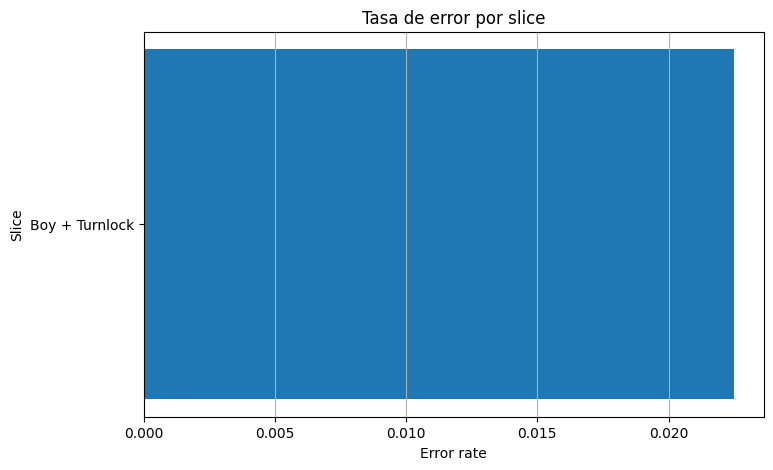

In [65]:
df_plot_error = df_metricas_slices[
    df_metricas_slices["slice_variable"] == "slice_modelo_parte"
].copy()

df_plot_error = df_plot_error.sort_values(by="error_rate", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(df_plot_error["slice"], df_plot_error["error_rate"])
plt.xlabel("Error rate")
plt.ylabel("Slice")
plt.title("Tasa de error por slice")
plt.grid(axis="x")
plt.show()

In [67]:
df_ejemplos_errores = df_error[df_error["error"] == True].copy()

df_ejemplos_errores = df_ejemplos_errores[
    ["filename", "modelo_cartera", "parte", "real", "prediccion", "y_prob", "tipo_error"]
].head(10)

df_ejemplos_errores["posible_causa"] = ""

display(df_ejemplos_errores)

,filename,modelo_cartera,parte,real,prediccion,y_prob,tipo_error,posible_causa
11,turnlock_0629.jpg,Boy,Turnlock,Genuine,Fake,0.413993,FN,
13,turnlock_0631.jpg,Boy,Turnlock,Genuine,Fake,0.499506,FN,
121,turnlock_0760.jpg,Boy,Turnlock,Genuine,Fake,0.494417,FN,
250,turnlock_0900.jpg,Boy,Turnlock,Genuine,Fake,0.311961,FN,
254,turnlock_0904.jpg,Boy,Turnlock,Genuine,Fake,0.211491,FN,
339,turnlock_0989.jpg,Boy,Turnlock,Genuine,Fake,0.314322,FN,
342,turnlock_0992.jpg,Boy,Turnlock,Genuine,Fake,0.352073,FN,
389,turnlock_1041.jpg,Boy,Turnlock,Genuine,Fake,0.259349,FN,
391,turnlock_1043.jpg,Boy,Turnlock,Genuine,Fake,0.259476,FN,
411,turnlock_1070.jpg,Boy,Turnlock,Genuine,Fake,0.365200,FN,


In [48]:
!pip install shap -q

In [68]:
df_error[["path", "filename", "parte", "modelo_cartera"]].head(20)

,path,filename,parte,modelo_cartera
0,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0617.jpg,Turnlock,Boy
1,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0618.jpg,Turnlock,Boy
2,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0619.jpg,Turnlock,Boy
3,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0620.jpg,Turnlock,Boy
4,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0621.jpg,Turnlock,Boy
5,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0622.jpg,Turnlock,Boy
6,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0624.jpg,Turnlock,Boy
7,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0625.jpg,Turnlock,Boy
8,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0626.jpg,Turnlock,Boy
9,/content/Chanel_Parts/genuine/bag---boy/turnlo...,turnlock_0627.jpg,Turnlock,Boy


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_5
Received: inputs=['Tensor(shape=(3, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_5
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


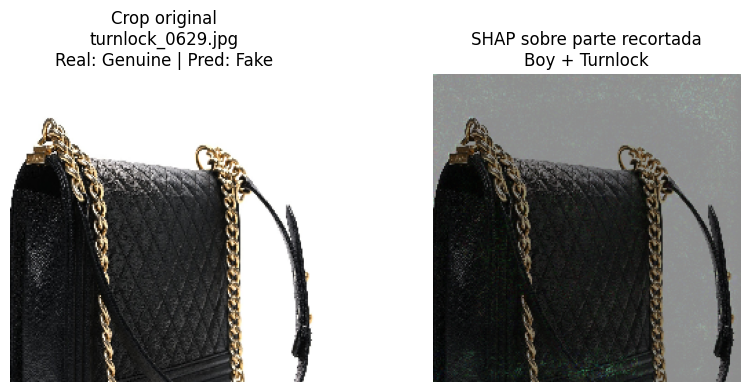

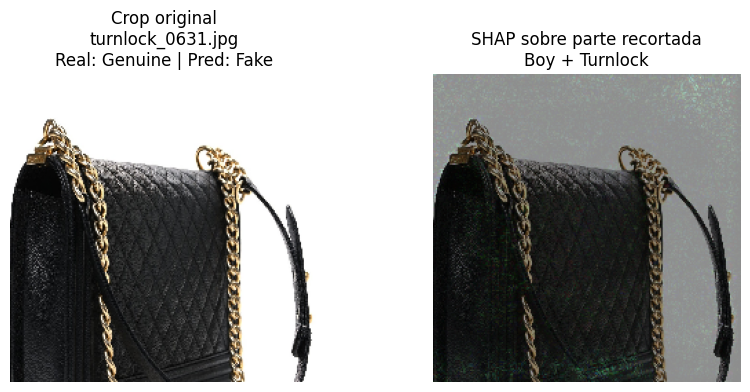

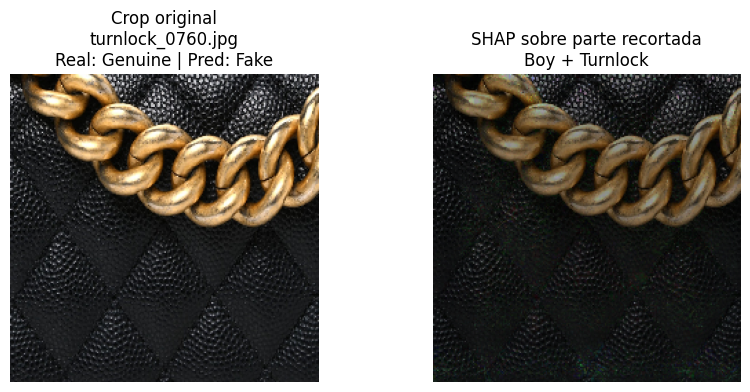

In [69]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

df_crops = df_error[
    df_error["parte"].isin(["Logo", "Turnlock"])
].copy()

df_crops_error = df_crops[df_crops["error"] == True].head(3)

background = []

for _, row in df_crops.sample(min(20, len(df_crops)), random_state=42).iterrows():
    img = load_img(row["path"], target_size=(224, 224))
    img = img_to_array(img).astype(np.float32)
    background.append(img)

background = np.array(background)

samples = []

for _, row in df_crops_error.iterrows():
    img = load_img(row["path"], target_size=(224, 224))
    img = img_to_array(img).astype(np.float32)
    samples.append(img)

samples = np.array(samples)

explainer = shap.GradientExplainer(model_resnet, background)

shap_values = explainer.shap_values(samples)

if isinstance(shap_values, list):
    shap_map = shap_values[0]
else:
    shap_map = shap_values

for i, (_, row) in enumerate(df_crops_error.iterrows()):
    img = samples[i] / 255.0

    mapa = np.mean(np.abs(shap_map[i]), axis=-1)
    mapa = mapa - mapa.min()
    mapa = mapa / (mapa.max() + 1e-8)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Crop original\n{row['filename']}\nReal: {row['real']} | Pred: {row['prediccion']}"
    )

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(mapa, cmap="jet", alpha=0.45)
    plt.axis("off")
    plt.title(
        f"SHAP sobre parte recortada\n{row['slice_modelo_parte']}"
    )

    plt.show()